# Download data (skips if data is already there

In [1]:
%run scripts/download_data.py

Skipping part1.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part1.tar.gz
Skipping part2.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part2.tar.gz
Skipping part3.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part3.tar.gz
Done.


# Unzip files  - skip if raw data directories already exist

In [4]:
import os

# Check if the folder is empty; if so, extract the files
if os.path.isdir("data/raw/utkface/part1"):
    print("Already extracted part1, skipping.")
else:
    !tar -xzf data/raw/utkface/part1.tar.gz -C data/raw/utkface

if os.path.isdir("data/raw/utkface/part2"):
    print("Already extracted part2, skipping.")
else:
    !tar -xzf data/raw/utkface/part2.tar.gz -C data/raw/utkface

if os.path.isdir("data/raw/utkface/part3"):
    print("Already extracted part3, skipping.")
else:
    !tar -xzf data/raw/utkface/part3.tar.gz -C data/raw/utkface


Already extracted part1, skipping.
Already extracted part2, skipping.
Already extracted part3, skipping.


# Preprocess data

In [5]:
%run scripts/preprocess_data.py

Reproducibility: Random seed set to 42
RAW_DATA_DIR exists: True
RAW_DATA_DIR path: data/raw/utkface
data/raw/utkface -> 3 files
data/raw/utkface/part1 -> 10137 files
data/raw/utkface/part2 -> 10719 files
data/raw/utkface/part3 -> 3253 files
Skipped samples: 5
Train: 19283 | Valid: 2410 | Test: 2411
Sample skipped: [('61_1_20170109142408075.jpg', 'invalid_filename'), ('61_3_20170109150557335.jpg', 'invalid_filename'), ('39_1_20170116174525125.jpg', 'invalid_filename'), ('53__0_20170116184028385.jpg', 'invalid_filename'), ('.DS_Store', 'invalid_filename')]

[train] age statistics (n=19283)
  min=1  max=116  mean=33.05  median=29.0  std=20.11

[val] age statistics (n=2410)
  min=1  max=116  mean=33.11  median=29.0  std=20.22

[test] age statistics (n=2411)
  min=1  max=116  mean=32.96  median=29.0  std=20.31


# Print selected config file

In [7]:
!cat configs/linear_regression_untrained.yaml

# Config file for ResNet18 untrained, to be used as backbone for linear regression.

experiment_name: "linear_regression_untrained"
model_name: "linear"  # linear, mlp, or mlp_dropout
seed: 42
pretrained: False
freeze_backbone: False    # Whether to fine-tune the pretrained model or just use it as a feature extractor
task: "regression"  # regression or classification
metric: "mae"       # mse for regression, accuracy for classification

# Data parameters
batch_size: 32
num_workers: 4
image_size: 224

# Training parameters
epochs: 10
learning_rate: 0.001
optimizer: "Adam"
#loss_function: "MSELoss" unused since we set it in train.py based on task
save_best: True

# MLP + Dropout
dropout: 0.2


# Train randomly initialized ResNet18

Reproducibility: Random seed set to 42
Pipeline Initialized. Loading data and model...
Setup complete! Ready to begin training epochs.


100%|###########################################################################################################################################| 76/76 [00:32<00:00,  2.37it/s, loss=342]


Epoch [1/10] Train Loss: 406.3422, Train MAE: 15.4388, Train MSE: 406.3422, Train Acc@3: 0.1394, Train Acc@5: 0.2349 | Val Loss: 341.8183, Val MAE: 14.1789, Val MSE: 341.8183, Val Acc@3: 0.1523, Val Acc@5: 0.2477, Val MAE: 14.1789


100%|###########################################################################################################################################| 76/76 [00:31<00:00,  2.41it/s, loss=347]


Epoch [2/10] Train Loss: 341.0201, Train MAE: 14.1647, Train MSE: 341.0201, Train Acc@3: 0.1553, Train Acc@5: 0.2552 | Val Loss: 346.6314, Val MAE: 13.7371, Val MSE: 346.6314, Val Acc@3: 0.1631, Val Acc@5: 0.2643, Val MAE: 13.7371


...

Epoch [8/10] Train Loss: 181.9916, Train MAE: 10.0393, Train MSE: 181.9916, Train Acc@3: 0.2195, Train Acc@5: 0.3540 | Val Loss: 246.3272, Val MAE: 12.4991, Val MSE: 246.3272, Val Acc@3: 0.1390, Val Acc@5: 0.2448, Val MAE: 12.4991


100%|###########################################################################################################################################| 76/76 [00:32<00:00,  2.32it/s, loss=162]


Epoch [9/10] Train Loss: 164.3669, Train MAE: 9.5199, Train MSE: 164.3669, Train Acc@3: 0.2326, Train Acc@5: 0.3751 | Val Loss: 162.1587, Val MAE: 9.2750, Val MSE: 162.1587, Val Acc@3: 0.2515, Val Acc@5: 0.3888, Val MAE: 9.2750


100%|###########################################################################################################################################| 76/76 [00:33<00:00,  2.24it/s, loss=163]


Epoch [10/10] Train Loss: 151.9017, Train MAE: 9.1658, Train MSE: 151.9017, Train Acc@3: 0.2432, Train Acc@5: 0.3852 | Val Loss: 162.7946, Val MAE: 9.2917, Val MSE: 162.7946, Val Acc@3: 0.2510, Val Acc@5: 0.4000, Val MAE: 9.2917
Saved model with MAE = 9.2750
Saved training stats history to /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/outputs/stats_history_linear_regression_untrained.npy
Training completely finished! Best Val Loss: 162.1587, Best Val MAE: 9.2750


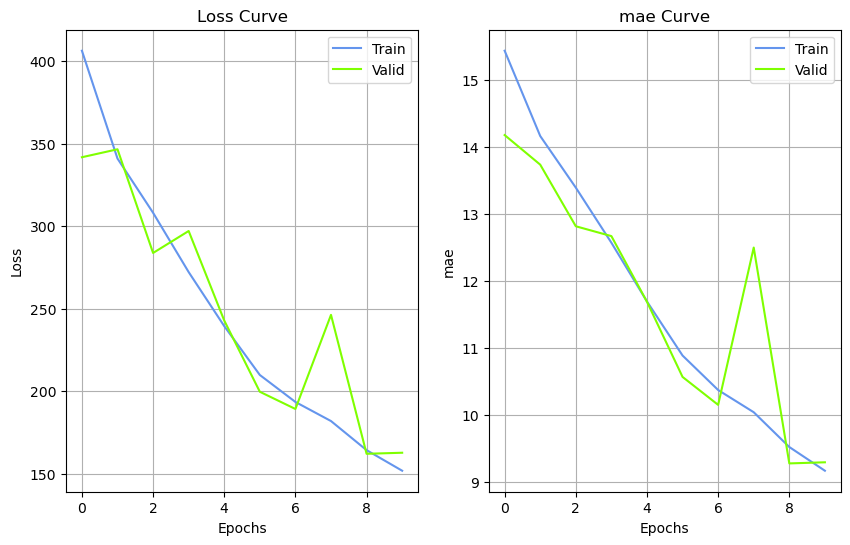

In [6]:
%run scripts/train.py --config configs/linear_regression_untrained.yaml

# Evaluate randomly initialized ResNet18

In [8]:
%run scripts/evaluate.py --config configs/linear_regression_untrained.yaml

Reproducibility: Random seed set to 42
Configuration loaded. Loading data and model...
Loading model from checkpoint: /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/outputs/checkpoint_linear_regression_untrained.pth


100%|###########################################################################################################################################| 76/76 [00:31<00:00,  2.43it/s, loss=154]


Evaluation Metrics — linear_regression_untrained
+--------+----------+
| Metric |    Value |
+--------+----------+
| MAE    |   9.0264 |
| MSE    | 153.9545 |
| Acc@3  |   0.2572 |
| Acc@5  |   0.4027 |
+--------+----------+
